# **Clasificación de caracteres Japoneses**

En este trabajo de Inteligencia Artificial, el objetivo es desarrollar modelos de clasificación utilizando diferentes algoritmos para identificar caracteres hiragana japoneses a partir de imágenes. El dataset contiene imágenes de 28x28 píxeles de 10 clases diferentes de caracteres hiragana. Los algoritmos a utilizar son Árboles de Decisión, Regresión, Random Forest y Redes Neuronales. Este problema se clasifica como una tarea de clasificación de imágenes.

# **Dataset y Variables**

El dataset contiene imágenes de los siguientes caracteres hiragana:

Aa (あ)

Ka (か)

Sa (さ)

Ta (た)

Na (な)

Ha (は)

Ma (ま)

Ya (や)

Ra (ら)

Wa (わ)

Cada imagen es una matriz de 28x28 píxeles, lo que da un total de 784 características por imagen. Cada característica representa el valor de intensidad de un píxel en escala de grises, donde 0 es negro y 255 es blanco. La etiqueta de clase de cada imagen indica el carácter hiragana correspondiente.


# **Descripción del Problema**
El problema de clasificación de caracteres hiragana japoneses es una tarea típica en el campo de reconocimiento de patrones y visión por computadora. Al tratarse de un dataset con 10 clases, el objetivo es entrenar modelos que puedan generalizar bien a nuevas imágenes no vistas durante el entrenamiento. La evaluación del rendimiento de los modelos se basará en métricas de precisión, matriz de confusión y reporte de clasificación.

# **Descripción de las Variables**
**Características:** 784 valores de píxeles (28x28 imágenes en escala de grises).

**Variable Objetivo:** Clase del carácter hiragana, representado por un número de 1 a 10.

El análisis de los resultados permitirá comparar la eficacia y eficiencia de diferentes algoritmos de aprendizaje automático en el reconocimiento de caracteres hiragana, proporcionando insights sobre cuál método es más adecuado para este tipo de tarea.

# **Importaciones de librerias**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.decomposition import PCA

from scipy.stats import zscore

Carga de datos de prueba

In [4]:
datos_japoneses = pd.read_csv('test_data.csv', encoding='ascii')
print(datos_japoneses)
print(datos_japoneses.info())

      Unnamed: 0  label  0   1   2  3  4   5    6    7  ...  774  775  776  \
0              0      2  0  97  35  0  0   0    0    0  ...    0    0    0   
1              1      9  0   0   0  0  0  24   72    0  ...  251  149    1   
2              2      3  0   0   0  0  0   0    0    0  ...    0    0    0   
3              3      8  0   0   0  0  0  17  138  195  ...    0    0    0   
4              4      3  0   0   0  0  0   0    0    0  ...    0    0    0   
...          ...    ... ..  ..  .. .. ..  ..  ...  ...  ...  ...  ...  ...   
9995        9995      4  0   0   0  0  0   0    0    0  ...    0    0    0   
9996        9996      0  0   0   0  0  0   0    0    0  ...    0    0    0   
9997        9997      9  0   0   0  0  0   0    0    0  ...   84   59    0   
9998        9998      4  0   0   0  0  0   0    0    0  ...    0    0    0   
9999        9999      2  0   0   0  0  0   0    0    0  ...    0    0    0   

      777  778  779  780  781  782  783  
0       0    0    0  

Al cargar los datos, observamos que están organizados en una matriz que consta de 10,000 filas, cada una representando una imagen, y 784 columnas que representan los valores de los píxeles que conforman dicha imagen. Además, hay dos columnas adicionales llamadas "Label" y "Unnamed", que representan las clases de los caracteres.

**Eliminacion de columnas Umnamed y label**

In [5]:
# Eliminar las columnas 'Unnamed: 0' y 'label'
df = datos_japoneses.drop(['Unnamed: 0', 'label'], axis=1)

**Presentacion de histograma para la visualizacion de la clasificacion actual en los datos de prueba, presentando como estan valanceadas las clases.**

In [6]:
# Eliminar la columna 'Unnamed: 0'
df2 = datos_japoneses.drop(['Unnamed: 0'], axis=1)

# Contar la cantidad de imágenes por cada label
label_counts = df2['label'].value_counts().sort_index()

# Contar la cantidad de imágenes por cada label o caracteristicas
label_counts = df2['label'].value_counts().sort_index()

# Crear un DataFrame para los datos del histograma
df_label_counts = pd.DataFrame({'Label': label_counts.index, 'Count': label_counts.values})

# Crear el histograma
fig_labels = px.bar(df_label_counts, x='Label', y='Count',
                    title='Cantidad de Imágenes por Cada Label',
                    labels={'Label': 'Label', 'Count': 'Cantidad de Imágenes'})

# Mostrar el histograma
fig_labels.show(renderer="browser")

Dado el gráfico de las clases existentes, podemos observar que este conjunto de datos cuenta con un total de 10,000 imágenes de 28x28 píxeles, clasificadas y divididas de manera equitativa en un total de 10 clases, que van desde la 0 hasta la 9. Esto da como resultado 1,000 imágenes pertenecientes a cada clase. Por lo tanto, no es necesario implementar ningún método de igualación para equilibrar los datos. Procederemos con las demás preparaciones y tratamientos de los datos.

Preparacion, tratamiento y redimencionamiento de datos:

In [7]:
#Traemos el df2 que tiene eliminado la columna de Unamed 0 y lo asignamos en datos_japonenes
datos_japoneses = df2

# Eliminar duplicados
datos_japoneses = datos_japoneses.drop_duplicates()

# Verificar valores faltantes o nulos en el conjunto de datos
print(datos_japoneses.isnull().sum())

# Separar las etiquetas y los datos
labels = datos_japoneses['label']
data = datos_japoneses.drop(['label'], axis=1)

# Crear un diccionario para almacenar los datos por label
label_data = {label: data[labels == label] for label in labels.unique()}

# Crear DataFrame para los datos normalizados
data_normalized_total = pd.DataFrame()

# Normalizar y calcular estadísticas por cada label
for label, df_label in label_data.items():
    # Aplicar la normalización Z-score a cada columna
    df_normalized = df_label.apply(zscore)

    # Añadir la columna de labels al DataFrame normalizado
    df_normalized['label'] = label

    # Reorganizar columnas para que 'label' sea la primera
    df_normalized = df_normalized[['label'] + [col for col in df_normalized.columns if col != 'label']]

    # Concatenar los datos normalizados al DataFrame total
    data_normalized_total = pd.concat([data_normalized_total, df_normalized])

# Asegurarse de que no haya valores NaN en el DataFrame normalizado
data_normalized_total = data_normalized_total.fillna(0)  # Reemplazar NaN por 0

# Extraer etiquetas y datos normalizados
labels_normalized = data_normalized_total['label']
data_normalized = data_normalized_total.drop(['label'], axis=1)

label    0
0        0
1        0
2        0
3        0
        ..
779      0
780      0
781      0
782      0
783      0
Length: 785, dtype: int64


En su totalidad, los datos no presentan duplicados ni valores nulos. Además, hemos realizado la normalización de los datos para llevar a cabo la reducción de dimensionalidad, utilizando los porcentajes que nos proporciona el Análisis de Componentes Principales (PCA).

**Varianza y Desviacion de los datos:**

In [8]:
# Calcular las estadísticas necesarias después de la normalización
stats = {label: {'varianza': df_label.var(axis=0), 'desviacion_estandar': df_label.std(axis=0)}
         for label, df_label in label_data.items()}

# Crear DataFrames para varianza y desviación estándar
varianza_df = pd.DataFrame({label: stats[label]['varianza'] for label in stats})
desviacion_estandar_df = pd.DataFrame({label: stats[label]['desviacion_estandar'] for label in stats})

# Mostrar las primeras filas de los DataFrames
print("Varianza por pixel por label:")
print(varianza_df)

print("\nDesviación estándar por pixel por label:")
print(desviacion_estandar_df)


# Mostrar las primeras filas del DataFrame normalizado
print("\nDataFrame normalizado:")
print(data_normalized_total.head())

# Mostrar las primeras filas del DataFrame original
print("\nDataFrame original:")
print(datos_japoneses.head())

# Mostrar las primeras filas del DataFrame normalizado
print("\nDataFrame normalizado:")
print(data_normalized_total.head())

# Mostrar las primeras filas del DataFrame original
print("\nDataFrame original:")
print(datos_japoneses.head())


Varianza por pixel por label:
              2            9            3            8           5  \
0     15.156933    47.175094    33.058158     0.000000   40.266642   
1     75.771603   323.322321   171.318643     0.012988   18.628384   
2    128.481432   340.224625   364.963487     5.771450   21.068168   
3    282.103604   527.258738   451.421177    70.968104   84.324604   
4    676.549586   945.527919   795.129814   306.448079  259.671591   
..          ...          ...          ...          ...         ...   
779  758.805925  1786.883888  4039.570690  1368.265365  780.234635   
780  751.487559  1636.160792  3467.919996   793.903504  410.440565   
781  641.096936  1002.473337  2373.377352   574.317213  253.947923   
782  433.253558   569.150186   351.544789   201.981212  113.032933   
783  108.076868   138.636072    49.188272    46.660051   46.442987   

              6           1           4            7           0  
0      0.625000    0.324000   88.754979     1.780572    1.0684

Grafica de Varianza

In [9]:
#ver la varianza
# Gráfica de la varianza explicada acumulada
pca = PCA()
pca.fit(data_normalized)
exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)

fig_area = px.area(
    x=range(1, exp_var_cumul.shape[0] + 1),
    y=exp_var_cumul,
    labels={"x": "# Components", "y": "Explained Variance"},
    title="Varianza explicada acumulada por PCA"
)
fig_area.show(renderer="browser")

La curva muestra un crecimiento rápido al principio, lo que indica que las primeras componentes principales capturan una gran cantidad de la varianza total de los datos.

A medida que agregamos más componentes, la tasa de incremento en la varianza explicada comienza a disminuir, indicando que las componentes adicionales capturan cada vez menos varianza adicional.

En particular, la gráfica sugiere que al incluir entre 400 y 500 componentes principales, podemos capturar una cantidad sustancial de la varianza total en los datos. Este rango de componentes logra retener una proporción significativa de la información original, lo que es crucial para garantizar que el modelo de aprendizaje automático mantenga su precisión y efectividad.

Más allá de los 500 componentes, la ganancia en varianza explicada se vuelve marginal, lo que sugiere un punto de rendimiento decreciente. Esto significa que agregar más componentes principales después de este punto no mejora significativamente la cantidad de información capturada, y puede no justificar el aumento en la complejidad del modelo.


**Porcentaje de varianza segun cantidad de componentes:**

In [10]:
#porcentaje de valor de importancia con respecto a demas variables
importanceOfPrincipalComponents = \
    pd.DataFrame(data=pca.explained_variance_ratio_)
importanceOfPrincipalComponents = importanceOfPrincipalComponents.T

print('Variance Captured by First 20 Principal Components: ',
      importanceOfPrincipalComponents.loc[:,0:19].sum(axis=1).values)
print('Variance Captured by First 50 Principal Components: ',
      importanceOfPrincipalComponents.loc[:,0:49].sum(axis=1).values)
print('Variance Captured by First 100 Principal Components: ',
      importanceOfPrincipalComponents.loc[:,0:99].sum(axis=1).values)
print('Variance Captured by First 200 Principal Components: ',
      importanceOfPrincipalComponents.loc[:,0:199].sum(axis=1).values)
print('Variance Captured by First 300 Principal Components: ',
      importanceOfPrincipalComponents.loc[:,0:299].sum(axis=1).values)
print('Variance Captured by First 500 Principal Components: ',
      importanceOfPrincipalComponents.loc[:,0:499].sum(axis=1).values)

Variance Captured by First 20 Principal Components:  [0.39837184]
Variance Captured by First 50 Principal Components:  [0.60816031]
Variance Captured by First 100 Principal Components:  [0.7743491]
Variance Captured by First 200 Principal Components:  [0.89998585]
Variance Captured by First 300 Principal Components:  [0.94722733]
Variance Captured by First 500 Principal Components:  [0.98381673]


Los resultados muestran que al obtener un 98% de la varianza explicada con los primeros 500 componentes, estos componentes conservan la mayor parte de los rasgos diferenciantes en las imágenes y su representación en las clases. Esto nos permite confiar en que la reducción de dimensionalidad no sacrifica información crucial, asegurando así la efectividad de los modelos de aprendizaje automático entrenados con estos datos reducidos.

**Reduccion de Componentes con PCA para el conjunto de datos:**

In [11]:
# Extraer las características (X) y las etiquetas (y)
X = datos_japoneses.iloc[:, 1:].values
y = datos_japoneses['label'].values

# Normalizar los valores de los píxeles
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Aplicar PCA para reducir la dimensionalidad a 500 componentes principales
pca = PCA(n_components=500)
X_pca = pca.fit_transform(X)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# Verificar tamaños de los conjuntos
print(f'Tamaño del conjunto de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de prueba: {X_test.shape}')

Tamaño del conjunto de entrenamiento: (7000, 500)
Tamaño del conjunto de prueba: (3000, 500)


# **Matriz de correlacion:**

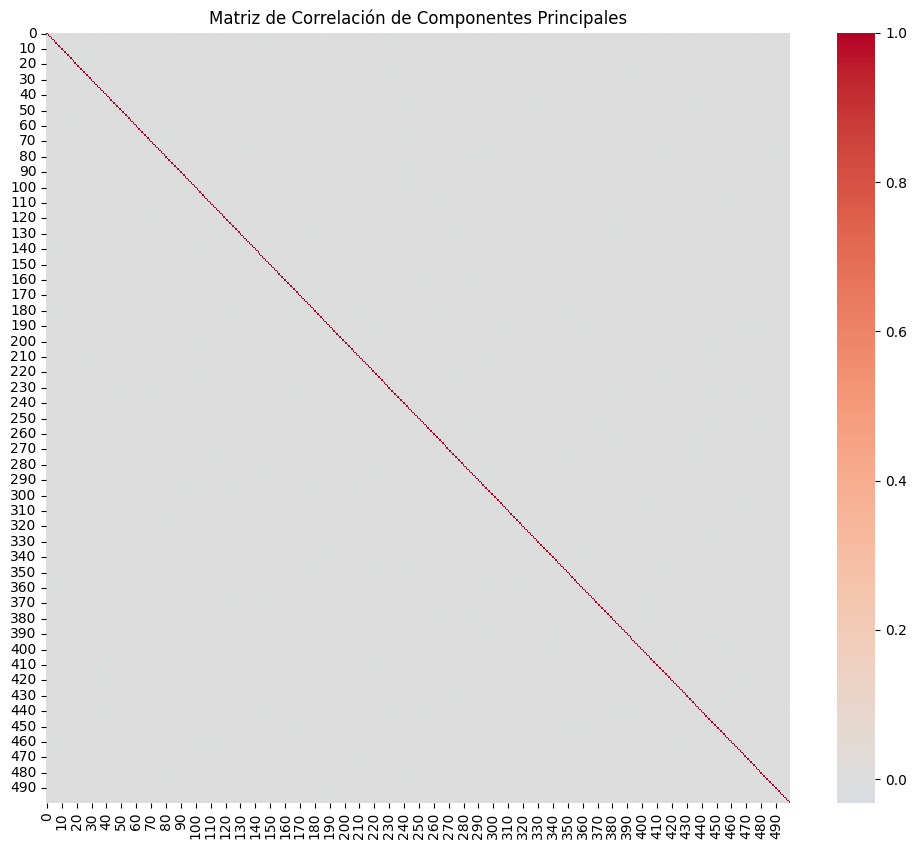

Número de pares de componentes altamente correlacionados (|corr| > 0.9): 0


In [12]:
# Calcular la matriz de correlación
corr_matrix = pd.DataFrame(X_train).corr()

# Visualizar la matriz de correlación utilizando un heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación de Componentes Principales')
plt.show()

# Análisis adicional para componentes altamente correlacionados
threshold = 0.9  # Definir un umbral de correlación
high_corr_pairs = [(i, j) for i in range(corr_matrix.shape[0]) for j in range(i+1, corr_matrix.shape[1]) if abs(corr_matrix.iloc[i, j]) > threshold]

print(f'Número de pares de componentes altamente correlacionados (|corr| > {threshold}): {len(high_corr_pairs)}')

Se calculó y visualizó la matriz de correlación para los 500 componentes principales utilizando un heatmap. El objetivo era identificar componentes altamente correlacionados que podrían indicar redundancia en la información.

**Resultados de la Matriz de Correlación:**

Número de pares de componentes altamente correlacionados (|corr| > 0.9): 0


No se encontraron componentes principales con una correlación absoluta mayor a 0.9. Esto sugiere que las componentes principales son bastante independientes entre sí.
La independencia entre componentes principales indica que la reducción de dimensionalidad realizada por PCA es efectiva, eliminando la redundancia y manteniendo componentes que contienen información única y relevante.

Aqui podemos apreciar que ya tenemos correctamente dividido nuestros conjunto de datos dividido conjuntos de entrenamiento y prueba, con 7000 muestras en el conjunto de entrenamiento y 3000 muestras en el conjunto de prueba, cada uno con 500 componentes principales.

# **Division de datos en conjunto mas pequeño para las pruebas gridSearch y la seleccion de hiperparametros:**

In [13]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_pca, y, test_size=0.8, random_state=42)

# **Implementacion de modelo de aprendizaje con regresion:**

In [14]:
# Inicializar el modelo
model = LogisticRegression(multi_class = 'multinomial', solver = 'lbfgs',  max_iter=2000)

# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

# Realizar predicciones con el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy * 100:.2f}%')

# Mostrar la matriz de confusión y el informe de clasificación
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print('Informe de clasificación:\n', cr)

labels = np.unique(y)

c:\Users\hp\Desktop\ia\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



Precisión del modelo: 63.47%
Informe de clasificación:
               precision    recall  f1-score   support

           0       0.72      0.75      0.73       301
           1       0.62      0.62      0.62       292
           2       0.54      0.48      0.51       316
           3       0.67      0.68      0.67       299
           4       0.65      0.61      0.63       326
           5       0.62      0.75      0.68       280
           6       0.63      0.64      0.63       303
           7       0.66      0.61      0.63       310
           8       0.60      0.65      0.62       260
           9       0.65      0.59      0.62       313

    accuracy                           0.63      3000
   macro avg       0.63      0.64      0.63      3000
weighted avg       0.63      0.63      0.63      3000



**Matriz**

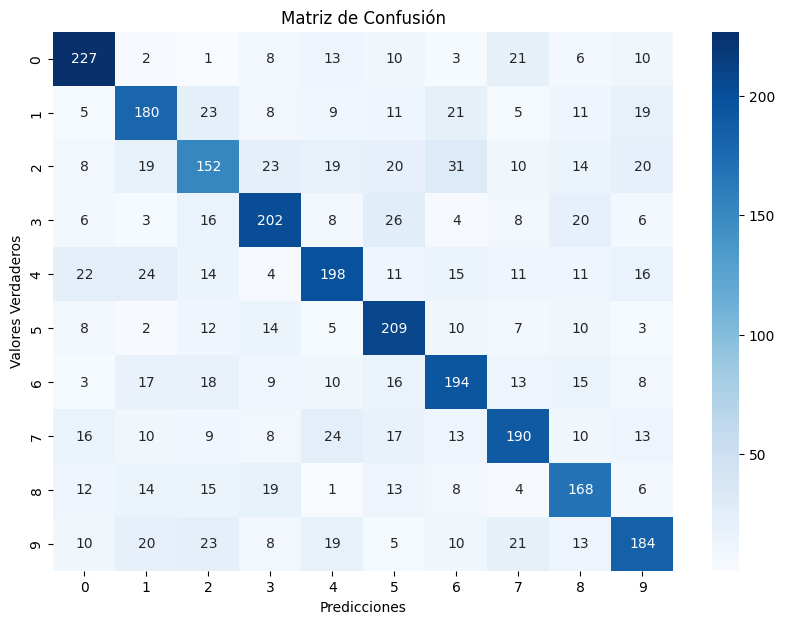

In [15]:
# Visualizar la matriz de confusión de manera gráfica
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión')
plt.show()

En la mariz de confusion podemos ver que se presentan bastantes errores de prediccion de algunas clases como lo son la clase 7 la cual fuera de la diagonal principal presenta valores relativamente altos que nos demuestran que hay algunas caracteristicas en el conjunto de datos que genera una confucion de esta clase con otras mas del conjunto, aparte de esto tambien podemos apreciar que el modelo logra obtener una prediccion del 63% de la clasificacion de las imagenes globales, no es un optimo mas sin embargo es medianamente aceptable y con un gran rango de mejora, por lo cual se optara por realizar una busqueda de las mejores combinaciones de hiperparametros con la funcion gridSearch y asi poder ejecutar nuevamente el modelo de regresion obteniendo un mejor resultado.

# **GridSearch Regresion**

In [16]:
"""# Inicializar el modelo de regresión logística
model = LogisticRegression(multi_class='multinomial')

# Definir la cuadrícula de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg', 'saga'],
    'max_iter': [100, 200, 500, 1000]
}

# Configurar la búsqueda en cuadrícula
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')

# Entrenar el modelo utilizando la búsqueda en cuadrícula
grid_search.fit(X_train2, y_train2)

# Obtener los mejores hiperparámetros
best_params = grid_search.best_params_
print(f'Mejores hiperparámetros: {best_params}')

# Realizar predicciones con el conjunto de prueba utilizando el mejor modelo
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test2)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy * 100:.2f}%')

# Mostrar la matriz de confusión y el informe de clasificación
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test2, y_pred)
print('Informe de clasificación:\n', cr)"""

"# Inicializar el modelo de regresión logística\nmodel = LogisticRegression(multi_class='multinomial')\n\n# Definir la cuadrícula de hiperparámetros\nparam_grid = {\n    'C': [0.01, 0.1, 1, 10, 100],\n    'penalty': ['l2'],\n    'solver': ['lbfgs', 'newton-cg', 'saga'],\n    'max_iter': [100, 200, 500, 1000]\n}\n\n# Configurar la búsqueda en cuadrícula\ngrid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')\n\n# Entrenar el modelo utilizando la búsqueda en cuadrícula\ngrid_search.fit(X_train2, y_train2)\n\n# Obtener los mejores hiperparámetros\nbest_params = grid_search.best_params_\nprint(f'Mejores hiperparámetros: {best_params}')\n\n# Realizar predicciones con el conjunto de prueba utilizando el mejor modelo\nbest_model = grid_search.best_estimator_\ny_pred = best_model.predict(X_test2)\n\n# Calcular la precisión\naccuracy = accuracy_score(y_test, y_pred)\nprint(f'Precisión del modelo: {accuracy * 100:.2f}%')\n\n# Mostrar la matriz de confusión y el informe de clasif

# **Implementación del modelo de aprendizaje con Árboles de Decisión**

In [17]:
# Crear el modelo de árbol de decisión
clf = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo
clf.fit(X_train, y_train)

# Predecir con el conjunto de prueba
y_pred = clf.predict(X_test)

# Evaluar el modelo
print("**********Decision Tree***************")
cm = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


**********Decision Tree***************
Accuracy: 0.5793333333333334
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.67      0.68       301
           1       0.58      0.51      0.54       292
           2       0.52      0.47      0.49       316
           3       0.59      0.62      0.60       299
           4       0.51      0.48      0.49       326
           5       0.58      0.64      0.61       280
           6       0.57      0.58      0.58       303
           7       0.62      0.65      0.63       310
           8       0.54      0.62      0.58       260
           9       0.60      0.57      0.58       313

    accuracy                           0.58      3000
   macro avg       0.58      0.58      0.58      3000
weighted avg       0.58      0.58      0.58      3000



**Matriz**

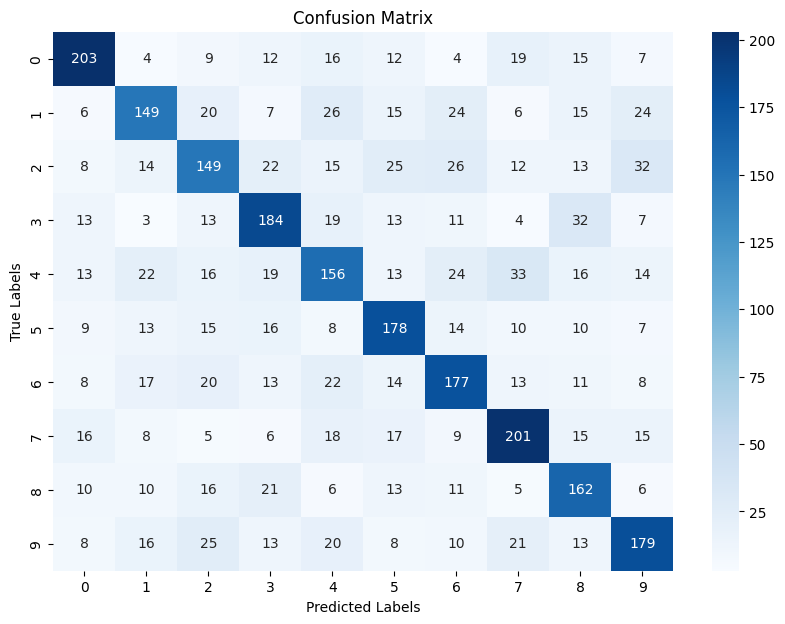

In [18]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

El árbol de decisión proporciona una aproximación al problema de clasificación de caracteres hiragana, pero su rendimiento indica que hay un espacio significativo para mejoras. Esto podría lograrse mediante técnicas como el uso de modelos más complejos (por ejemplo, Random Forest o Redes Neuronales) o el ajuste de hiperparámetros. El modelo de Arboles de desicion nos da como resultado un porcentaje de clasificacion global muy bajo, lo cual indica que el modelo no clasificó correctamente todas las clases teniendo como resultado solo el 58% de las imagenes globales y gracias a la matriz visual podemos apreciar que se da un problema debido a las caracteristicas similares entre los datos.

# **GridSearch para arbol de desicion**

In [19]:
# GridSearchCV para encontrar los mejores hiperparámetros
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train2, y_train2)

print(f'Best Parameters: {grid_search.best_params_}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


# **Entrenar arbol con parametros de GridSearch**

In [20]:
# Entrenar el modelo con los mejores hiperparámetros
best_clf = grid_search.best_estimator_
best_clf.fit(X_train, y_train)

# Predecir con el conjunto de prueba
y_pred = best_clf.predict(X_test)

# Evaluar el modelo
print("**********Decision Tree with GridSearchCV***************")
cm = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_test, y_pred))

**********Decision Tree with GridSearchCV***************
Accuracy: 0.6176666666666667
Confusion Matrix:
 [[214   1   2  11  11  13   4  16  17  12]
 [  8 172  21   5  13  14  26   6  18   9]
 [ 10  19 171  17   6  26  17  12  15  23]
 [  7  15  15 201   7  20   5   8   9  12]
 [ 23  22  17   4 168  12  29  22   5  24]
 [  6  17  18  12   5 193   9   9   7   4]
 [  2  33  16   8  22   7 183  13  10   9]
 [ 14  10  10   8  24   5  18 198  10  13]
 [ 17  18   5  14  12  10   7   6 164   7]
 [ 10  24  18   4  22   4  13  17  12 189]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70       301
           1       0.52      0.59      0.55       292
           2       0.58      0.54      0.56       316
           3       0.71      0.67      0.69       299
           4       0.58      0.52      0.55       326
           5       0.63      0.69      0.66       280
           6       0.59      0.60      0.60       303
       

**Matriz**

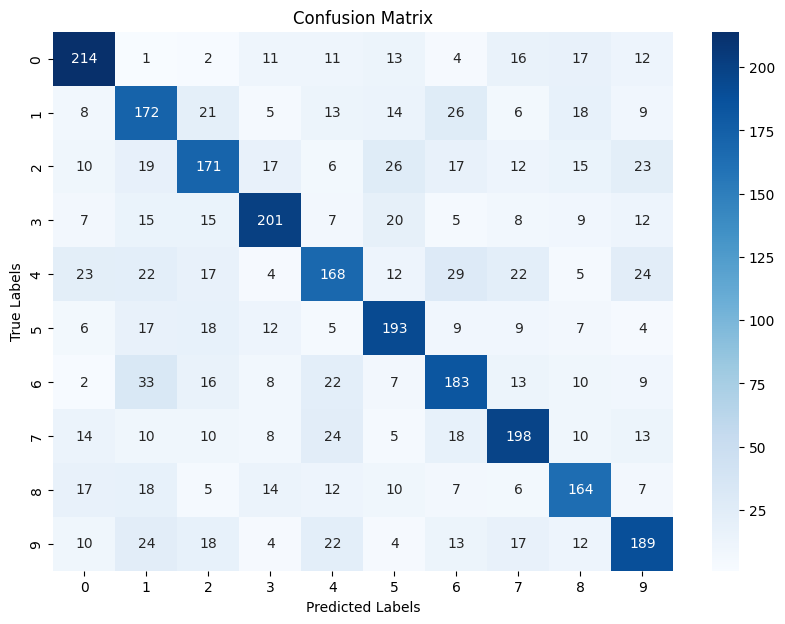

In [21]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_clf.classes_, yticklabels=best_clf.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# **Implementación del modelo de aprendizaje con Random Forest**

In [22]:
model_rf = RandomForestClassifier(n_estimators=100,random_state=42)

# Entrenar el modelo con los datos de entrenamiento
model_rf.fit(X_train, y_train)

# Realizar predicciones con el conjunto de prueba
y_pred_rf = model_rf.predict(X_test)

# Calcular la precisión
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Precisión del modelo de Random Forest: {accuracy_rf * 100:.2f}%')

cm_rf = confusion_matrix(y_test, y_pred_rf)
cr_rf = classification_report(y_test, y_pred_rf)
#print('Matriz de confusión de Random Forest:\n', cm_rf)
print('Informe de clasificación de Random Forest:\n', cr_rf)

cross_val_scores = cross_val_score(model_rf, X_train, y_train, cv=2)
train_accuracy = model_rf.score(X_train, y_train) * 100
test_accuracy = model_rf.score(X_test, y_test) * 100

print("Precisión del entrenamiento:", "{:.3f}%".format(train_accuracy))
print("Precisión de prueba:", "{:.3f}%".format(test_accuracy))


print("Resultados de la validación cruzada:")
print(cross_val_scores)
print("Precisión media: {:.2f}".format(cross_val_scores.mean()))

Precisión del modelo de Random Forest: 77.00%
Informe de clasificación de Random Forest:
               precision    recall  f1-score   support

           0       0.75      0.92      0.83       301
           1       0.75      0.72      0.74       292
           2       0.77      0.64      0.70       316
           3       0.71      0.87      0.78       299
           4       0.74      0.67      0.70       326
           5       0.83      0.82      0.83       280
           6       0.74      0.73      0.74       303
           7       0.83      0.83      0.83       310
           8       0.76      0.77      0.76       260
           9       0.83      0.75      0.79       313

    accuracy                           0.77      3000
   macro avg       0.77      0.77      0.77      3000
weighted avg       0.77      0.77      0.77      3000

Precisión del entrenamiento: 100.000%
Precisión de prueba: 77.000%
Resultados de la validación cruzada:
[0.71171429 0.718     ]
Precisión media: 0.71


**Matriz:**

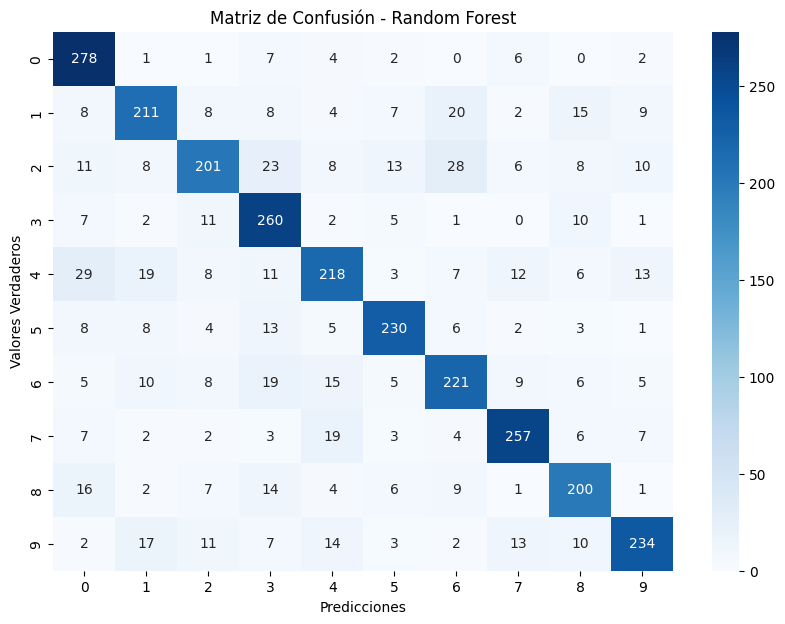

In [23]:
# Visualizar la matriz de confusión de manera gráfica para Random Forest
plt.figure(figsize=(10, 7))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

El informe de clasificación muestra varias métricas de rendimiento para cada clase, incluyendo precisión, recall (sensibilidad), f1-score y support (número de muestras de cada clase en el conjunto de prueba).

Observamos unos valores de precisión superiores al 80% Una precisión alta significa que el modelo comete pocos falsos positivos. Las clases 1 y 6 fueron las de menor precisión se debe considerar mejorar el preprocesamiento para mejorar esta metrica.

Un recall alto significa que el modelo comete pocos falsos negativos. encontramos que la mayoria de clases cuentan con una sensibilidad alta sin embargo la clase 2 y 4 presentan muchos falsos negativos. f1-score representa la precisión y recall.

La matriz de confusión nos muestra la clasificación de las predicciones. Lo principal es remitirse a la diagonal principal donde se encuentran las predicciones correctamente clasificadas por cada clase por ejemplo para la clase 0 tenemos Predicciones correctas: 199

Predicciones incorrectas:

1 muestra fue predicha como clase 2.

7 muestras fueron predichas como clase 4.

2 muestras fueron predichas como clase 7.

Total de muestras: 199 + 1 + 7 + 2 = 209

## **Aplicacion de GridSearchCV Ramdom Forest:**

In [24]:
from sklearn.preprocessing import label_binarize
model_rf = RandomForestClassifier()

param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20, 30]
}
grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=5, scoring='accuracy')
# Entrenar el modelo utilizando GridSearchCV
grid_search.fit(X_train2, y_train2)

# Obtener los mejores hiperparámetros
best_params = grid_search.best_params_
print(f'Mejores hiperparámetros: {best_params}')

y_pred_rf = grid_search.predict(X_test2)

# Calcular la precisión
accuracy_rf = accuracy_score(y_test2, y_pred_rf)
print(f'Precisión del modelo de Random Forest: {accuracy_rf * 100:.2f}%')

cm_rf = confusion_matrix(y_test2, y_pred_rf)
cr_rf = classification_report(y_test2, y_pred_rf)
#print('Matriz de confusión de Random Forest:\n', cm_rf)
print('Informe de clasificación de Random Forest:\n', cr_rf)


Mejores hiperparámetros: {'max_depth': 10, 'n_estimators': 100}
Precisión del modelo de Random Forest: 67.83%
Informe de clasificación de Random Forest:
               precision    recall  f1-score   support

           0       0.73      0.75      0.74       817
           1       0.64      0.70      0.67       786
           2       0.73      0.44      0.55       814
           3       0.57      0.82      0.68       798
           4       0.63      0.55      0.59       812
           5       0.69      0.83      0.75       767
           6       0.72      0.62      0.67       816
           7       0.72      0.70      0.71       801
           8       0.69      0.71      0.70       790
           9       0.72      0.68      0.70       799

    accuracy                           0.68      8000
   macro avg       0.68      0.68      0.67      8000
weighted avg       0.69      0.68      0.67      8000



El resultado obtenido con GridSearchCV nos rpesenta un resultado menor al anteriormente conseguido con el base, no obstante nos reafirma que el n_estimators igual a 100 es la opcion mas optima para la seleccion del modelo.

# **Entrenamiento y pruebas Redes Neuronales:**

In [25]:
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder

# Codificación de las etiquetas
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Construir y entrenar el modelo MLP con la configuración específica
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=100,
    momentum=0.9,
    random_state=42
)
mlp_classifier.fit(X_train, y_train_encoded)

# Predicciones en el conjunto de prueba
y_pred = mlp_classifier.predict(X_test)

# Evaluación del modelo
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f'Accuracy: {accuracy}')
print(classification_report(y_test_encoded, y_pred))

Accuracy: 0.817
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       301
           1       0.82      0.78      0.80       292
           2       0.74      0.70      0.72       316
           3       0.83      0.87      0.85       299
           4       0.80      0.77      0.78       326
           5       0.80      0.88      0.84       280
           6       0.79      0.83      0.81       303
           7       0.85      0.82      0.84       310
           8       0.80      0.83      0.82       260
           9       0.85      0.78      0.81       313

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



**Exactitud General:** El modelo muestra una exactitud del 82%, lo cual es satisfactorio ya que clasifica de manera correcta en gran medida las clases del conjunto de datos.

**Desempeño por Clases:** La precisión y el recall varían entre las clases, con la clase 0 mostrando el mejor desempeño (precisión de 0.87 y recall de 0.91) y la clase 2 mostrando un desempeño relativamente menor (precisión de 0.77 y recall de 0.72).

**Balance del Modelo:** El modelo es bastante equilibrado en términos de precisión y recall en la mayoría de las clases, lo que indica que no está sesgado hacia una clase específica (no esta sobre entrenado a ninguna clase).

## **Predicciones:**

In [26]:
# Predicciones en el conjunto de entrenamiento
y_train_pred = mlp_classifier.predict(X_train)

# Evaluar el rendimiento en el conjunto de entrenamiento
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
print(f'Accuracy en el conjunto de entrenamiento: {train_accuracy}')
print('Reporte de clasificación en el conjunto de entrenamiento:')
print(classification_report(y_train_encoded, y_train_pred))

# Predicciones en el conjunto de prueba
y_test_pred = mlp_classifier.predict(X_test)

# Evaluar el rendimiento en el conjunto de prueba
test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
print(f'Accuracy en el conjunto de prueba: {test_accuracy}')
print('Reporte de clasificación en el conjunto de prueba:')
print(classification_report(y_test_encoded, y_test_pred))

Accuracy en el conjunto de entrenamiento: 1.0
Reporte de clasificación en el conjunto de entrenamiento:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       699
           1       1.00      1.00      1.00       708
           2       1.00      1.00      1.00       684
           3       1.00      1.00      1.00       701
           4       1.00      1.00      1.00       674
           5       1.00      1.00      1.00       720
           6       1.00      1.00      1.00       697
           7       1.00      1.00      1.00       690
           8       1.00      1.00      1.00       740
           9       1.00      1.00      1.00       687

    accuracy                           1.00      7000
   macro avg       1.00      1.00      1.00      7000
weighted avg       1.00      1.00      1.00      7000

Accuracy en el conjunto de prueba: 0.817
Reporte de clasificación en el conjunto de prueba:
              precision    recall  f1-score  

**Sobreajuste:** La exactitud perfecta en el conjunto de entrenamiento (1.0) en contraste con la exactitud del 82% en el conjunto de prueba indica que el modelo está sobreajustado. Esto significa que aprendio muy bien los patrones del conjunto de entrenamiento pero no completamente del conjunto de prueba.

**Balance del Modelo:** A pesar del sobreajuste, el modelo es bastante equilibrado en términos de precisión y recall en la mayoría de las clases, lo que indica que no está sesgado hacia una clase específica.

## **Redes La mejor combinación de parámetros con gridSearchCV**

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

param_grid = [{'hidden_layer_sizes' : [(100,), (50,), (80,)], 'max_iter':[500, 1000]},
              {'alpha': [0.001, 0.01, 0.1]}]
model = MLPClassifier()
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train2, y_train2)

print(grid_search.best_params_)
predictions = grid_search.predict(X_test2)
print(accuracy_score(y_test2, predictions))
print("Confusion matrix:\n%s" % metrics.confusion_matrix(y_test2, predictions))

c:\Users\hp\Desktop\ia\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\hp\Desktop\ia\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\hp\Desktop\ia\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\hp\Desktop\ia\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\hp\Desktop\ia\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarn

{'alpha': 0.1}
0.757875
Confusion matrix:
[[687   2   0  18  43   9   1  27  12  18]
 [  4 580  31  11  34  12  41   9  37  27]
 [  3  31 513  55  27  46  55  15  44  25]
 [  4  14  24 666   7  36   8  15  17   7]
 [ 50  53  27  24 533  15  30  23  22  35]
 [ 10   9  15  31   8 639  26   3  15  11]
 [  3  50  33  17  24  27 613  18  21  10]
 [ 20   7  16   9  35  14  14 629  34  23]
 [ 19  17  28  26  13  25  22   6 624  10]
 [ 12  41  47  11  36  11  16  16  30 579]]


En el resultado de la prueba de hiperparametros podemos apreciar que la mejor alpha es de 0.1, mas sin enmbargo no nos presenta de manera mas especifica la combiancion con las demas hiperparameros dentro del modelo, por lo cual se realizara de una mejor visualizacion a continuacion:

   param_alpha param_hidden_layer_sizes  param_max_iter  mean_test_score  \
0          NaN                   (100,)           500.0           0.6865   
1          NaN                   (100,)          1000.0           0.6790   
2          NaN                    (50,)           500.0           0.6620   
3          NaN                    (50,)          1000.0           0.6825   
4          NaN                    (80,)           500.0           0.6770   
5          NaN                    (80,)          1000.0           0.6815   
6        0.001                      NaN             NaN           0.6730   
7        0.010                      NaN             NaN           0.6855   
8        0.100                      NaN             NaN           0.7230   

   rank_test_score  
0                2  
1                6  
2                9  
3                4  
4                7  
5                5  
6                8  
7                3  
8                1  


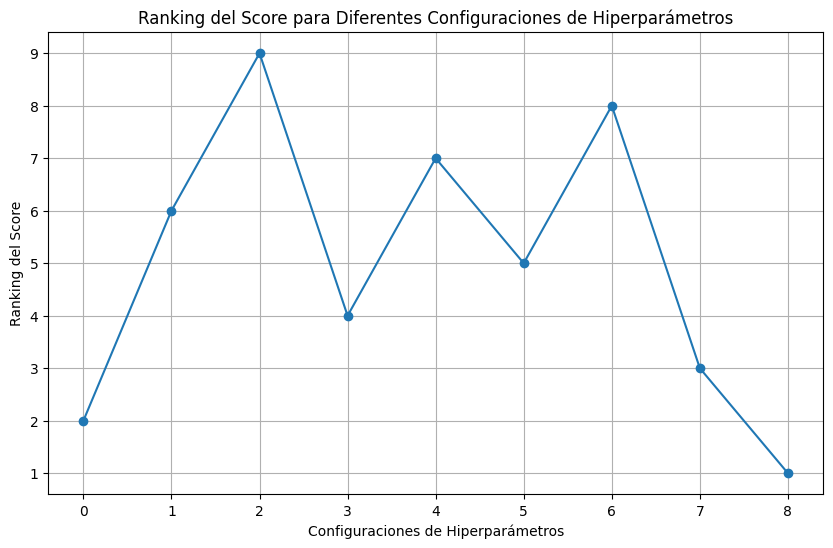

In [28]:
# Convertir los resultados de la búsqueda de hiperparámetros en un DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Mostrar los detalles de todas las combinaciones de hiperparámetros
print(results_df[['param_alpha', 'param_hidden_layer_sizes', 'param_max_iter', 'mean_test_score', 'rank_test_score']])

# Visualizar los resultados de la búsqueda de hiperparámetros
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(results_df['rank_test_score'], marker='o')
plt.xlabel('Configuraciones de Hiperparámetros')
plt.ylabel('Ranking del Score')
plt.title('Ranking del Score para Diferentes Configuraciones de Hiperparámetros')
plt.grid(True)
plt.show()

Entonces, la mejor combinación de hiperparámetros sería alpha=0.1, hidden_layer_sizes=(80,), y max_iter=1000. Esto se basa en los puntajes medios de validación cruzada y el ranking de estos puntajes en comparación con las otras combinaciones probadas.

Gracias a

# **Teniendo en cuenta el resultado de los mejores parametros procedemos a ajustar el modelo Redes:**

In [ ]:
# Construir y entrenar el modelo MLP con la configuración específica
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(80,),
    activation='relu',
    solver='adam',
    alpha=0.1,
    max_iter=1000,
    momentum=0.9,
    random_state=42
)
mlp_classifier.fit(X_train, y_train_encoded)

# Predicciones en el conjunto de prueba
y_pred = mlp_classifier.predict(X_test)

# Evaluación del modelo
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f'Accuracy: {accuracy}')
print(classification_report(y_test_encoded, y_pred))

Accuracy: 0.8593333333333333
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       301
           1       0.87      0.84      0.85       292
           2       0.81      0.79      0.80       316
           3       0.88      0.91      0.90       299
           4       0.85      0.81      0.83       326
           5       0.83      0.88      0.85       280
           6       0.84      0.85      0.85       303
           7       0.88      0.86      0.87       310
           8       0.86      0.88      0.87       260
           9       0.86      0.87      0.86       313

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



Accuracy: 0.8193333333333334
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       301
           1       0.82      0.77      0.79       292
           2       0.77      0.72      0.74       316
           3       0.83      0.85      0.84       299
           4       0.80      0.75      0.78       326
           5       0.81      0.89      0.85       280
           6       0.80      0.84      0.82       303
           7       0.86      0.83      0.84       310
           8       0.82      0.85      0.83       260
           9       0.82      0.81      0.81       313

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000

Comparando ambos resultados, la prueba con los hiperparametros base y con los mejores escogidos del grid podemos ver una mejora que aunque pequeña es significativa, dandonos un valor del 4% mejor en rendimiento.

# **Comparacion entre metodos:**

# Regresion Lineal:
Precisión del modelo: 63.53%
Informe de clasificación:
               precision    recall  f1-score   support

           0       0.71      0.76      0.73       301
           1       0.63      0.65      0.64       292
           2       0.54      0.50      0.52       316
           3       0.67      0.66      0.67       299
           4       0.65      0.59      0.62       326
           5       0.62      0.74      0.67       280
           6       0.64      0.65      0.64       303
           7       0.65      0.61      0.63       310
           8       0.59      0.64      0.61       260
           9       0.63      0.58      0.60       313

    accuracy                           0.64      3000
   macro avg       0.63      0.64      0.63      3000
weighted avg       0.64      0.64      0.63      3000

# Arboles de desicion:
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.74      0.71       301
           1       0.52      0.61      0.56       292
           2       0.60      0.54      0.57       316
           3       0.73      0.70      0.71       299
           4       0.61      0.53      0.57       326
           5       0.64      0.66      0.65       280
           6       0.59      0.59      0.59       303
           7       0.64      0.65      0.64       310
           8       0.62      0.61      0.62       260
           9       0.63      0.64      0.64       313

    accuracy                           0.63      3000
   macro avg       0.63      0.63      0.63      3000
weighted avg       0.63      0.63      0.63      3000

# Ramdom Forest
Precisión del modelo de Random Forest: 77.40%
Informe de clasificación de Random Forest:
               precision    recall  f1-score   support

           0       0.75      0.92      0.83       301
           1       0.77      0.72      0.75       292
           2       0.83      0.63      0.71       316
           3       0.71      0.87      0.78       299
           4       0.74      0.72      0.73       326
           5       0.82      0.81      0.82       280
           6       0.76      0.74      0.75       303
           7       0.81      0.79      0.80       310
           8       0.74      0.80      0.77       260
           9       0.83      0.76      0.79       313

    accuracy                           0.77      3000
   macro avg       0.78      0.78      0.77      3000
weighted avg       0.78      0.77      0.77      3000

Precisión del entrenamiento: 100.000%
Precisión de prueba: 77.400%
Resultados de la validación cruzada:
[0.71714286 0.714     ]
Precisión media: 0.72

# Redes
Accuracy: 0.8593333333333333
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       301
           1       0.87      0.84      0.85       292
           2       0.81      0.79      0.80       316
           3       0.88      0.91      0.90       299
           4       0.85      0.81      0.83       326
           5       0.83      0.88      0.85       280
           6       0.84      0.85      0.85       303
           7       0.88      0.86      0.87       310
           8       0.86      0.88      0.87       260
           9       0.86      0.87      0.86       313

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000

# Comparacion de metodos:
### Comparación del Rendimiento de los Métodos de Clasificación en un Conjunto de Datos de Imágenes en Escala de Grises

Se realizó un estudio comparativo del rendimiento de diferentes algoritmos de clasificación en un conjunto de datos compuesto por 10,000 imágenes en escala de grises de 28x28 píxeles. Los algoritmos evaluados fueron: Redes Neuronales (MLPClassifier), Random Forest, Árboles de Decisión y Regresión Logística.

####Redes Neuronales (MLPClassifier)
- **Precisión del conjunto de prueba**: 85.93%
- **Informe de clasificación**:
  - La precisión y recall en cada clase oscilaron entre 0.80 y 0.91.
  - F1-score promedio ponderado: 0.86
- **Precisión del conjunto de entrenamiento**: 100%

Las redes neuronales mostraron un rendimiento superior en comparación con los otros métodos, con una precisión de prueba de 85.93%. Este modelo demostró una alta capacidad de generalización y rendimiento consistente a través de todas las clases. Sin embargo, el alto rendimiento en el conjunto de entrenamiento podría indicar un sobreajuste, a pesar de los buenos resultados en el conjunto de prueba.

####Random Forest
- **Precisión del conjunto de prueba**: 77.40%
- **Informe de clasificación**:
  - La precisión y recall en cada clase oscilaron entre 0.63 y 0.92.
  - F1-score promedio ponderado: 0.77
- **Precisión del conjunto de entrenamiento**: 100%
- **Resultados de validación cruzada**: Precisión media de 0.72

Random Forest presentó un rendimiento aceptable con una precisión de prueba de 77.40%. Este método mostró una buena capacidad para manejar la variabilidad del conjunto de datos, aunque se observó una discrepancia significativa entre la precisión del conjunto de entrenamiento y la de prueba, lo que sugiere un posible sobreajuste.

####Árboles de Decisión
- **Precisión del conjunto de prueba**: 63.00%
- **Informe de clasificación**:
  - La precisión y recall en cada clase oscilaron entre 0.53 y 0.74.
  - F1-score promedio ponderado: 0.63

Los árboles de decisión tuvieron un rendimiento modesto con una precisión de prueba del 63.00%. Este método mostró limitaciones en la capacidad de generalización y en el manejo de la complejidad de los datos de imágenes.

####Regresión Logística
- **Precisión del conjunto de prueba**: 63.53%
- **Informe de clasificación**:
  - La precisión y recall en cada clase oscilaron entre 0.50 y 0.76.
  - F1-score promedio ponderado: 0.64

La regresión logística obtuvo una precisión de prueba del 63.53%, similar a la de los árboles de decisión. Aunque es un modelo lineal y simple, mostró limitaciones significativas al clasificar imágenes complejas y de alta dimensionalidad como las del conjunto de datos utilizado.

###Conclusión
En resumen, las redes neuronales demostraron ser el mejor método de clasificación para el conjunto de datos de imágenes en escala de grises, superando significativamente a Random Forest, Árboles de Decisión y Regresión Logística. A pesar del buen rendimiento de las redes neuronales, es crucial abordar el posible sobreajuste observado.
